In [1]:
%run  start.py

# KMeans(K-평균) 군집분석

In [2]:
from sklearn.cluster import KMeans

In [3]:
customer = pd.read_csv('data/customer_join4.csv')
customer.isnull().sum()

customer_id         0
name                0
class               0
gender              0
start_date          0
end_date         2842
campaign_id         0
is_deleted          0
class_name          0
price               0
campaign_name       0
mean                0
median              0
max                 0
min                 0
routine_flg         0
calc_date           0
membership_p        0
dtype: int64

In [4]:
customer.head(2)

,customer_id,name,class,gender,start_date,end_date,campaign_id,is_deleted,class_name,price,campaign_name,mean,median,max,min,routine_flg,calc_date,membership_p
0,OA832399,XXXX,C01,F,2015-05-01,NaN,CA1,0,0_종일,10500,2_일반,4.833333,5.0,8,2,1,2019-03-31,46
1,PL270116,XXXXX,C01,M,2015-05-01,NaN,CA1,0,0_종일,10500,2_일반,5.083333,5.0,7,3,1,2019-03-31,46


In [7]:
## 원하는 항목만 추출
customer_clustering = customer[["mean", "median","max", "min", "membership_p"]].\
    rename(columns={'mean': '평균', 'median': '중앙값','max': '최대값','min': '최소값',
                    'membership_p': '회원기간'})
customer_clustering.head()

,평균,중앙값,최대값,최소값,회원기간
0,4.833333,5.0,8,2,46
1,5.083333,5.0,7,3,46
2,4.583333,5.0,6,3,46
3,4.833333,4.5,7,2,46
4,3.916667,4.0,6,1,46


In [8]:
sc = StandardScaler()
customer_clustering_sc = sc.fit_transform(customer_clustering)
customer_clustering_sc

array([[-0.28120614, -0.13367635,  0.08117747, -0.5336197 ,  2.04709147],
       [-0.14054502, -0.13367635, -0.37992814, -0.02114919,  2.04709147],
       [-0.42186727, -0.13367635, -0.84103375, -0.02114919,  2.04709147],
       ...,
       [ 1.50050144,  1.46662237,  0.08117747,  2.54120338, -1.3350627 ],
       [ 3.18843493,  3.06692109,  1.46449428,  4.07861492, -1.3350627 ],
       [ 2.62579043,  2.53348819,  1.00338868,  3.56614441, -1.3350627 ]],
      shape=(4192, 5))

In [9]:
kmeans = KMeans(n_clusters=4, random_state=41)  ###  클러스터링 모델구축 (그룹 4개로 지정)
clusters = kmeans.fit(customer_clustering_sc)   ###  클러스터링 실행

customer_clustering["cluster"] = clusters.labels_   ###  클러스터링 결과 저장

print(customer_clustering["cluster"].unique())   ## 데이터 그룹 개수와 각 번호
customer_clustering

[0 3 1 2]


,평균,중앙값,최대값,최소값,회원기간,cluster
0,4.833333,5.0,8,2,46,0
1,5.083333,5.0,7,3,46,0
2,4.583333,5.0,6,3,46,0
3,4.833333,4.5,7,2,46,0
4,3.916667,4.0,6,1,46,0
...,...,...,...,...,...,...
4187,8.000000,8.0,8,8,0,2
4188,10.000000,10.0,10,10,0,2
4189,8.000000,8.0,8,8,0,2
4190,11.000000,11.0,11,11,0,2


In [10]:
customer_clustering.to_csv("data/customer_clustering2.csv",index=False)

In [11]:
df = pd.read_csv('data/customer_clustering2.csv')
df

,평균,중앙값,최대값,최소값,회원기간,cluster
0,4.833333,5.0,8,2,46,0
1,5.083333,5.0,7,3,46,0
2,4.583333,5.0,6,3,46,0
3,4.833333,4.5,7,2,46,0
4,3.916667,4.0,6,1,46,0
...,...,...,...,...,...,...
4187,8.000000,8.0,8,8,0,2
4188,10.000000,10.0,10,10,0,2
4189,8.000000,8.0,8,8,0,2
4190,11.000000,11.0,11,11,0,2


<Axes: xlabel='cluster', ylabel='최소값'>

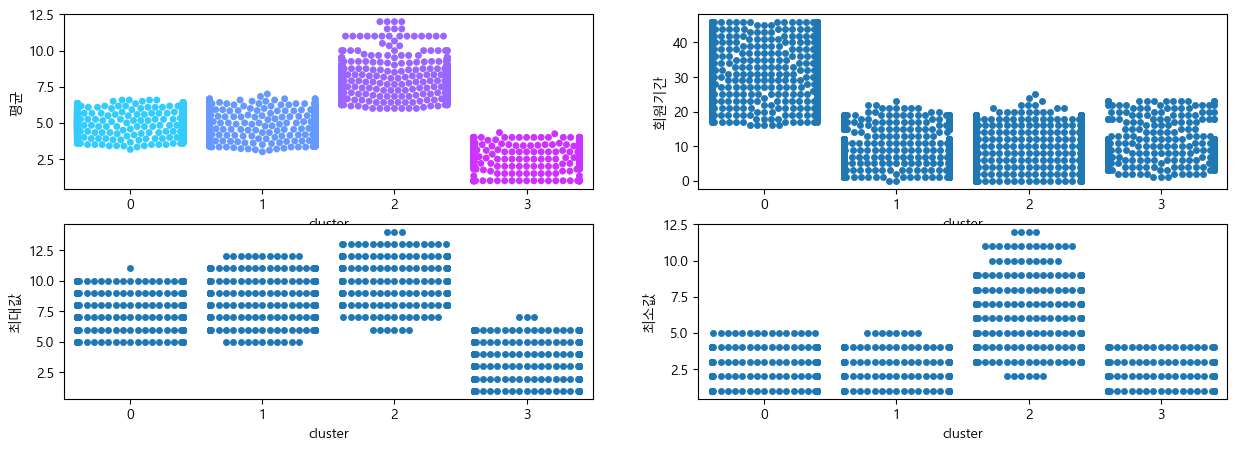

In [13]:
fig = plt.figure(figsize=(15, 5))   
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)
ax4 = fig.add_subplot(2, 2, 4)

sns.swarmplot(x="cluster", y="평균", data=df,  ax=ax1, palette='cool') 
sns.swarmplot(x="cluster", y="회원기간", data=df, ax=ax2)
sns.swarmplot(x="cluster", y="최대값", data=df, ax=ax3)
sns.swarmplot(x="cluster", y="최소값", data=df, ax=ax4)